In [1]:
from fluke import DDict, FlukeENV
from fluke.data import DataSplitter
from fluke.data.datasets import Datasets
from fluke.evaluation import ClassificationEval
from fluke.algorithms.fedavg import FedAVG

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

FlukeENV().set_seed(42)
device = 'mps' if torch.backends.mps.is_available() else 'cpu'
FlukeENV().set_device(device)
print(f"Device: {device}")

Device: mps


In [2]:
from CNN import *
mnist_data = Datasets.get('mnist', path='./data')
num_clients, num_rounds = 5, 15

**Data Distribution**

```I used label_dirichlet_skew method from fluke library where data is distributed biasely for each client```

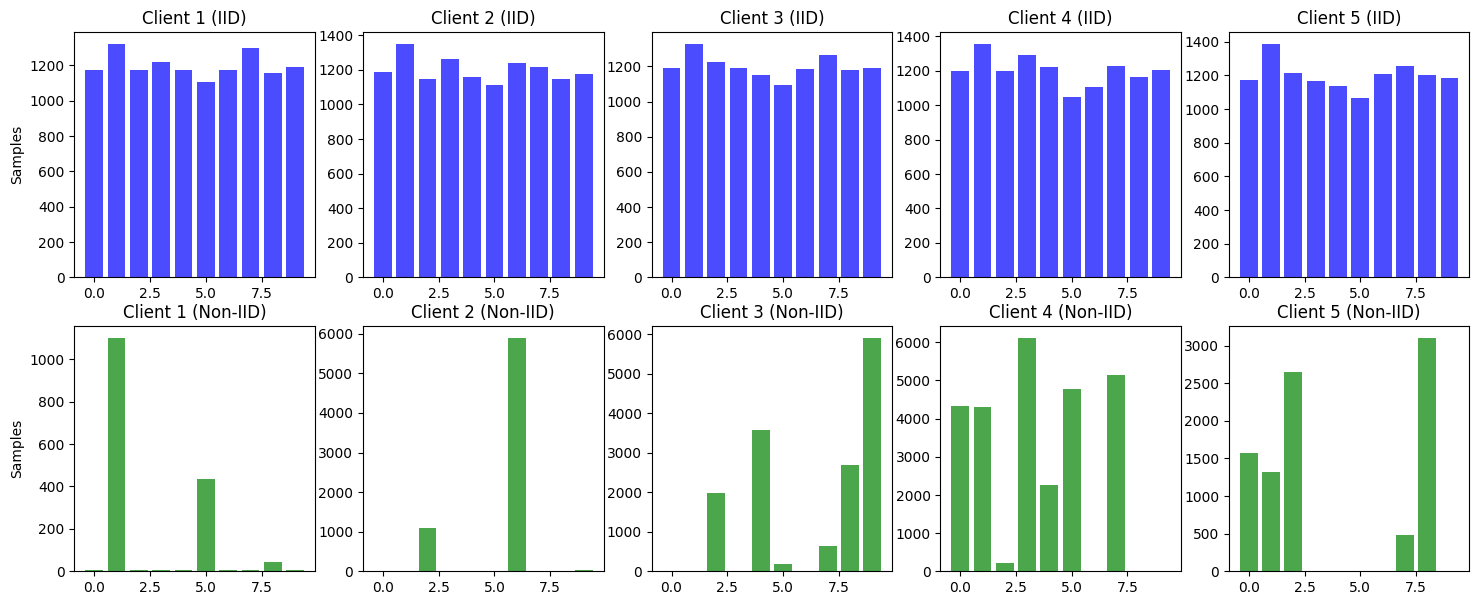

In [3]:
evaluator = ClassificationEval(eval_every=1, n_classes=10)
FlukeENV().set_evaluator(evaluator)
FlukeENV().set_eval_cfg(pre_fit=False, post_fit=False, locals=False, server=True)

(iid_train, _), _ = DataSplitter(dataset=mnist_data, distribution='iid').assign(num_clients, batch_size=32)
(noniid_train, _), _ = DataSplitter(dataset=mnist_data, distribution='dir',
    dist_args=DDict(min_ex_class=4)).assign(num_clients, batch_size=32)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
for i in range(num_clients):
    for row, data, color, label in [(0, iid_train, 'b', 'IID'), (1, noniid_train, 'g', 'Non-IID')]:
        counts = [0] * 10
        for l in data[i].tensors[1].numpy(): counts[int(l)] += 1
        axes[row][i].bar(range(10), counts, color=color, alpha=0.7)
        axes[row][i].set_title(f'Client {i+1} ({label})')
        if i == 0: axes[row][i].set_ylabel('Samples')

## IID vs Non-IID

In [4]:
def run_fl_rounds(distribution, dist_args=None, label=""):
    ev = ClassificationEval(eval_every=1, n_classes=10)
    FlukeENV().set_evaluator(ev)
    hp = DDict(model=MNIST_CNN(),
           client=DDict(batch_size=32, local_epochs=3, loss='CrossEntropyLoss',
                     optimizer=DDict(lr=0.01),
                     scheduler=DDict(step_size=10, gamma=1.0)),
                     server=DDict(weighted=False))
    
    algo = FedAVG(
            n_clients=num_clients,
            data_splitter=DataSplitter(dataset=mnist_data,
                                       distribution=distribution,
                                       dist_args=dist_args), 
                                       hyper_params=hp)
    accs = []
    log_msgs = []
    for r in range(num_rounds):
        algo.run(n_rounds=1, eligible_perc=1.0, finalize=False)
        acc = algo.server.evaluate(ev, algo.server.test_set, round=r+1)
        accs.append(acc['accuracy'] * 100)
        if (r+1) % 5 == 0:
            log_msgs.append(f"  [{label}] Round {r+1}: {accs[-1]:.2f}%")
    for msg in log_msgs:
        print(msg)
        
    return accs

In [5]:
mnist_data = Datasets.get('mnist', path='./data')
num_clients, num_rounds = 5, 15

iid_accs = run_fl_rounds('iid', label="IID")

noniid_accs = run_fl_rounds('dir', dist_args=DDict(min_ex_class=4), label="Non-IID")

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

  [Non-IID] Round 5: 90.19%
  [Non-IID] Round 10: 95.17%
  [Non-IID] Round 15: 96.01%


## Results

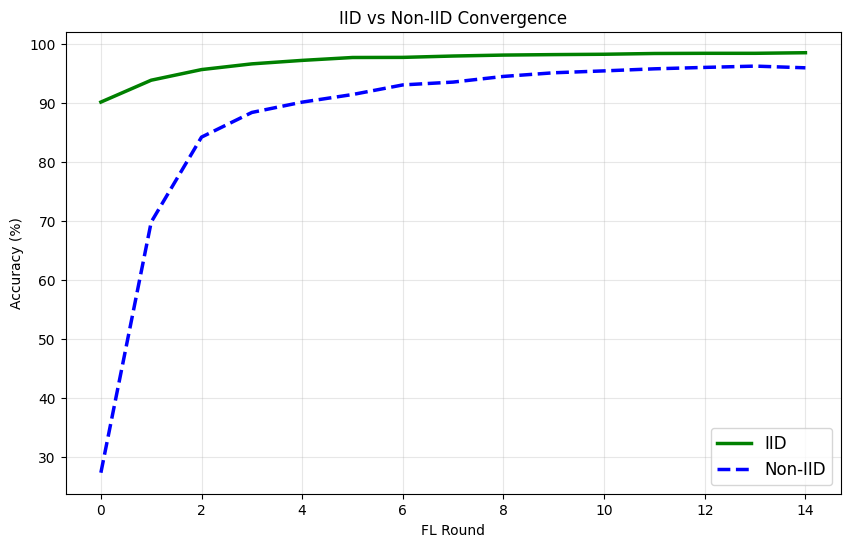

IID: 98.57%,  Non-IID: 96.01%


In [6]:
plt.figure(figsize=(10, 6))
plt.plot(iid_accs, label='IID', color='g', linewidth=2.5)
plt.plot(noniid_accs, label='Non-IID', color='b', linewidth=2.5, linestyle='--')
plt.xlabel('FL Round'); plt.ylabel('Accuracy (%)')
plt.title('IID vs Non-IID Convergence')
plt.legend(fontsize=12); plt.grid(True, alpha=0.3)
plt.show()


print(f"IID: {iid_accs[-1]:.2f}%,  Non-IID: {noniid_accs[-1]:.2f}%")